### [Seq 2 Seq architecture]
- encoder + decoder 구조로 이루어진 모든 모델 통칭
- 문장을 입력받아 다른 문장으로 만드는 모든 기계 번역/요약 모델의 기본 틀


ex) Google translator, Papago. 번역 AI가 문장을 하나의 context vector로 압축하고, 이를 바탕으로 단어를 순차적으로 예측해나감.

1. 순환 신경망 이용 - '문맥의 흐름'을 기억하기 좋음
2. 주로 번역에서 사용 목적 연구
3. 인코더: 문장을 이해함. ex) '나는 너를 사랑해' 문장 context 기억함. [Context Vector] 만들어짐
   
   디코더: 문장 생성 역할, 인코더의 context vector를 초기값으로 참고함, 'I Love You'

LSTM: 은닉상태, 셀상태
- 은닉상태: 단기기억, 세세한 정보
- 셀상태: 장기기억, broad한 정보
- 두 가지를 포함한 것이 바로 context vector

sequence data: 입력, 출력단어 개수 다름 -> 한국어(입력)-영어(출력) 번역시 단어 개수 다른 것과 비슷한 맥락?

seq 2 seq arc:
- 임의의 길이를 가진 입력 sequence -> 다른 길이의 출력 sequence
- encoder: 
  - 1. LSTM 사용하여 단기기억 h, 장기기억 c 함께 업데이트 -> long term memory dependency를 방지
  - 2. 최종 context vector C: 입력 문장의 마지막 단어 시점에서 도출된 최종 h+c set가 C에 압축
  - decoder와 달리 분류작업이 없음


- decoder:
  - 1. encoder가 전달한 C를 초기 h, c상태로 설정 후 번역할 언어 단어 하나씩 예측하여 생성
    - Teacher Forcing: 학습 초반부에는 정답을 직접 주입하여 잘못된 예측 경로 빠지는 것 방지 + 학습속도 올림 
  - 2. 문장 시작 토큰 `<sos>`, 문장 종료 토큰 `<eos>`
  - 3. decoder는 분류에 대한 모델, 즉 '나는'이 왔을 때 다음 단어를 각각 분류해서 확률을 완성한 뒤 가장 높은 확률의 단어를 선택함 
  - vacob size만큼 분류가 됨, 10000개 단어면 10000개 분류
  - 마지막은 분류층이 추가되어 마지막 분류작업을 함

# 5장 1강: 시퀀스-투-시퀀스 구조의 이해
## 3. PyTorch를 활용한 LSTM 기반 영-한 단어 번역 실습

- token
- `Linear()`
- `LSTM()`
- `context vector`: 거리 계산->맞는 단어 확률 계산?
- `<pad>`: 남아있는 공간을 채우는 특수 토큰 (같은 사이즈가 아니면 학습이 불가능함)
- `<sos>`: 문장 시작 알림
- `<eos>`: 문장 종료 알림

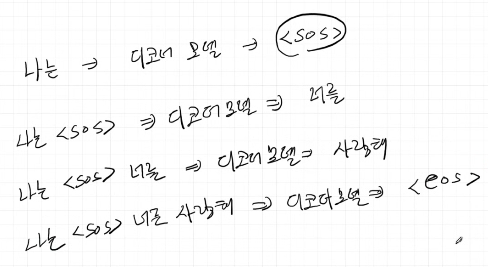

### 3.1 인코더(Encoder) 구현

In [4]:
import torch
import torch.nn as nn

class EncoderLSTM(nn.Module):
    def __init__(self, input_size, embed_size, hidden_size): #흐름: 입력->임베딩->은닉
        super().__init__()

        # 처음 임베딩 레이어 정의
        self.embedding = nn.Embedding(input_size, embed_size) 
        # 임베딩 레이어는 입력 단어를 고정된 크기의 벡터로 변환하는 역할을 합니다. 여기서 input_size는 어휘의 크기(단어 수)를 나타내고, embed_size는 각 단어를 표현할 임베딩 벡터의 차원을 나타냅니다.

        # LSTM 레이어 정의
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True) # LSTM 레이어는 시퀀스 데이터를 처리하는 순환 신경망(RNN)
        # batch_first=True는 입력 텐서의 첫 번째 차원이 배치 크기임을 나타냅니다. 즉, 입력 텐서의 형태가 (batch_size, sequence_length, embed_size)임을 의미합니다.
    
    # 순방향 전파
    def forward(self, x): 
        embedded = self.embedding(x) # 입력 x를 임베딩 벡터로 변환
        outputs, (hidden, cell) = self.lstm(embedded) # 임베딩 벡터를 LSTM에 통과시켜 출력과 은닉 상태(hidden, cell)를 얻음. 
        # (hidden, cell) -> Context Vector
        return hidden, cell # 순방향 전파에서 마지막 hidden, cell (context vector) 반환

    

### 3.2 디코더(Decoder) 구현

In [3]:
class DecoderLSTM(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size):
        super().__init__()

        # 임베딩 레이어 정의 
        self.embedding = nn.Embedding(output_size, embed_size) # 출력 단어를 임베딩 벡터로 변환

        # LSTM 레이어 정의
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

        # 출력층 추가(분류기)
        self.output = nn.Linear(hidden_size, output_size) # 전체 토큰에서 확률이 높은 것을 분류해줘야 하기 때문에 Linear 레이어를 사용하여 hidden_size를 output_size로 변환

    # hidden_state 초기값은 encoder에서 나온 context vector(hidden, cell)
    def forward(self, x, hidden_state):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded, hidden_state) # LSTM에 임베딩 벡터와 hidden_state를 입력으로 넣어줌 
        prediction = self.output(outputs.squeeze(1)) # LSTM의 출력값을 Linear 레이어에 통과시켜 최종 예측값을 얻음, squeeze(1) 3차원 텐서를 2차원 텐서로 변환(batch, output_size)

        return prediction, (hidden, cell) # 예측값과 hidden, cell 반환


### 3.3 모델 완성 및 테스트 (데이터 전처리, 학습, 추론)

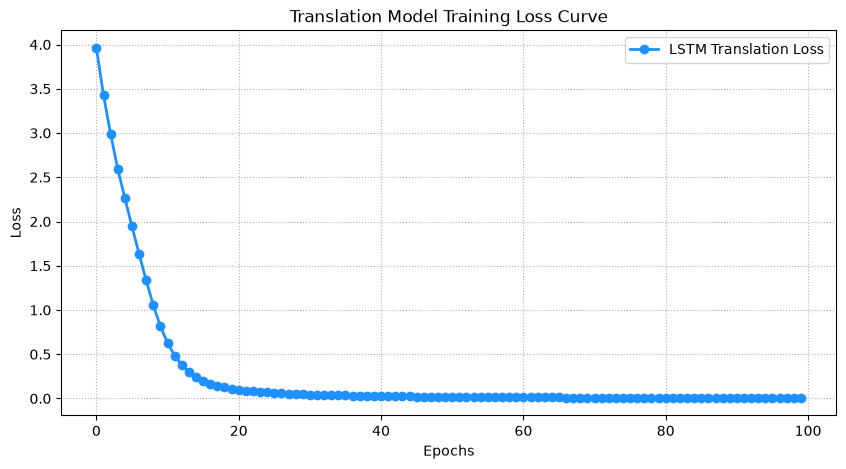


--- [추론 테스트] 번역 결과 확인 ---
입력(ENG): hello   ===>  출력(KOR): 안녕
입력(ENG): car     ===>  출력(KOR): 차
입력(ENG): cat     ===>  출력(KOR): 고양이
입력(ENG): dog     ===>  출력(KOR): 개
입력(ENG): sun     ===>  출력(KOR): 태양


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim

# ==========================================
# 데이터 준비 및 어휘 사전(Vocabulary) 구축
# ==========================================
pairs = [ #encoder= 영단어 src, decoder= 한글 tgt 학습
    ("hello", "안녕"), 
    ("car", "차"),
    ("cat", "고양이"),
    ("dog", "개"),
    ("sun", "태양")
]

# 특수 토큰 설정 (<pad>: 패딩, <sos>: 시작 신호, <eos>: 종료 신호)
src_words = ["<pad>"] + list(sorted(list(set([p[0] for p in pairs])))) # <pad> : 패딩 토큰을 추가하여 입력 시퀀스의 길이를 맞추기 위해 사용
tgt_words = ["<pad>", "<sos>", "<eos>"] + list(sorted(list(set([p[1] for p in pairs])))) # sos, eos: 시작과 종료 토큰을 추가하여 디코더가 번역을 시작하고 종료할 수 있도록 함

# 인덱스 변환 맵 생성 -> 단어->인덱스, 인덱스->단어로 만들어 모델이 예측한 값을 실제 단어로 변환할 수 있고, 단어를 인덱스로 변환하여 모델에 입력할 수 있음
src_w2i = {w: i for i, w in enumerate(src_words)}
src_i2w = {i: w for i, w in enumerate(src_words)}
tgt_w2i = {w: i for i, w in enumerate(tgt_words)}
tgt_i2w = {i: w for i, w in enumerate(tgt_words)}

def encode_src(sent): return [src_w2i[sent]] # 영어 단어를 숫자로 바꿈
def encode_tgt(sent): return [tgt_w2i["<sos>"]] + [tgt_w2i[sent]] + [tgt_w2i["<eos>"]] # 한글 단어를 숫자로 바꿈, tgt는 decoder에서 시작과 종료를 알 수 있도록 <sos>와 <eos>를 추가


embed_size = 16 # 단어를 16차원 벡터로 임베딩하여 단어를 컴퓨터가 이해하기 좋은 숫자 묶음으로 바꿈
hidden_size = 16 # LSTM의 기억해둘 정보의 크기 ex) encoder의 메모리 공간=16칸

# 모델 선언 및 지정된 디바이스로 할당
encoder = EncoderLSTM(len(src_words), embed_size, hidden_size)
decoder = DecoderLSTM(len(tgt_words), embed_size, hidden_size)

# loss function과 optimizer 정의
encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.01) #모델 파라미터를 조금씩 수정, lr=한번 고칠 때 0.01만큼 수정
decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# 텐서 데이터 변환 후 가속 디바이스로 연동 (PyTorch가 사용할 수 있는 Tensor 형태로 변환)
src_tensors = [torch.tensor([encode_src(p[0])], dtype=torch.long) for p in pairs]
tgt_tensors = [torch.tensor([encode_tgt(p[1])], dtype=torch.long) for p in pairs]

# ==========================================
# 모델 학습 루프 실행 (교사 강요 기법 적용)
# ==========================================
losses = [] # 학습 오차(Loss) 기록용 리스트

for epoch in range(100): # 100번 반복 학습
    epoch_loss = 0
    for src_t, tgt_t in zip(src_tensors, tgt_tensors):
        # gradient 지우기 (지난번 계산한 실수 기록을 지우기)
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()
        
        # [인코더] 컨텍스트 벡터 추출
        enc_hidden, enc_cell = encoder(src_t)
        
        # [디코더] 초기 상태를 인코더의 출력값으로 연동
        decoder_hidden_state = (enc_hidden, enc_cell)
        decoder_input = tgt_t[:, 0:1]  # 첫 시작 단어는 <sos> 토큰
        
        loss = 0
        for t in range(1, tgt_t.size(1)):
            prediction, decoder_hidden_state = decoder(decoder_input, decoder_hidden_state)
            target = tgt_t[:, t]
            loss += criterion(prediction, target)
            
            # [교사 강요] 모델의 예측값 대신 실제 정답 데이터를 다음 시점의 입력으로 강제 설정
            decoder_input = tgt_t[:, t:t+1]
            
        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()
        
        epoch_loss += loss.item()
        
    losses.append(epoch_loss / len(pairs))

# ==========================================
# 학습 오차(Loss) 하강 곡선 시각화
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(losses, color='dodgerblue', linewidth=2, linestyle='-', marker='o', label='LSTM Translation Loss')
plt.title('Translation Model Training Loss Curve', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

# ==========================================
# 모델 추론 및 번역 성능 최종 테스트
# ==========================================
print("\n--- [추론 테스트] 번역 결과 확인 ---")
with torch.no_grad():
    for src_t, p in zip(src_tensors, pairs):
        enc_hidden, enc_cell = encoder(src_t)
        decoder_hidden_state = (enc_hidden, enc_cell)
        
        # 입력용 시작 토큰 생성 및 디바이스 연동
        decoder_input = torch.tensor([[tgt_w2i["<sos>"]]], dtype=torch.long)
        translated_sentence = []
        
        for _ in range(5):  # 출력 최대 길이 제한
            prediction, decoder_hidden_state = decoder(decoder_input, decoder_hidden_state)
            predicted_idx = prediction.argmax(1).item()  # 최고 점수를 얻은 토큰 인덱스 선택
            
            if predicted_idx == tgt_w2i["<eos>"]:
                break
                
            translated_sentence.append(tgt_i2w[predicted_idx])
            
            # 자가 예측(기본 추론): 모델이 직접 예측한 단어를 다음 시점의 입력값 및 디바이스 설정으로 갱신
            decoder_input = torch.tensor([[predicted_idx]], dtype=torch.long)
            
        print(f"입력(ENG): {p[0]:6s}  ===>  출력(KOR): {' '.join(translated_sentence)}")

In [7]:
print(src_w2i)
print(src_i2w)
print(tgt_w2i)
print(tgt_i2w)

{'<pad>': 0, 'car': 1, 'cat': 2, 'dog': 3, 'hello': 4, 'sun': 5}
{0: '<pad>', 1: 'car', 2: 'cat', 3: 'dog', 4: 'hello', 5: 'sun'}
{'<pad>': 0, '<sos>': 1, '<eos>': 2, '개': 3, '고양이': 4, '안녕': 5, '차': 6, '태양': 7}
{0: '<pad>', 1: '<sos>', 2: '<eos>', 3: '개', 4: '고양이', 5: '안녕', 6: '차', 7: '태양'}
